In [1]:
import os
import pandas as pd
import re

# 设置文件目录
directory = './grid_search_new'

# 定义存储结果的列表
data = []

# 获取所有以throughput_general_nested_booking_limit_limit_开头的文件
for filename in os.listdir(directory):
    if filename.startswith('throughput_general_nested_booking_limit_limit_') and filename.endswith('.csv'):
        # 使用正则表达式提取qps和rates
        match = re.match(r'throughput_general_nested_booking_limit_limit_\d+_qps=(\d+)_rates=_([\d_]+)_batch_size_\d+\.csv', filename)
        if match:
            qps = int(match.group(1))  # 提取qps并转换为整数
            rates = match.group(2)  # 提取rates作为字符串
            file_path = os.path.join(directory, filename)  # 获取文件路径
            data.append([file_path, qps, rates])

# 将数据转换为DataFrame
df1 = pd.DataFrame(data, columns=['file_path_nested', 'qps_nested', 'rates_nested'])

#print(df1)

In [2]:
directory = './sarathi_match_grid_search'

# 定义存储结果的列表
data = []

# 获取所有以throughput_general_nested_booking_limit_limit_开头的文件
for filename in os.listdir(directory):
    if filename.startswith('throughput_') :
        # 使用正则表达式提取qps和rates
        match = re.match(r'throughput_sarathi_batch_size_\d+_qps=(\d+)\.csv', filename)
        if match:
            qps = int(match.group(1))  # 提取qps并转换为整数
            file_path = os.path.join(directory, filename)  # 获取文件路径
            data.append([file_path, qps])

# 将数据转换为DataFrame
df2 = pd.DataFrame(data, columns=['file_path_sarathi', 'qps_sarathi'])

In [3]:
import pandas as pd

# 假设 df1 和 df2 已经定义
df3 = pd.merge(df1, df2, left_on='qps_nested', right_on='qps_sarathi', how='inner')

# 选择需要的列，假设你需要保留所有来自 df1 和 df2 的列
df3 = df3[['file_path_nested', 'file_path_sarathi','rates_nested', 'qps_sarathi', 'qps_nested']]

In [4]:
df3

,file_path_nested,file_path_sarathi,rates_nested,qps_sarathi,qps_nested
0,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_32_8_4_1,109,109
1,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,32_8_4_2_1,47,47
2,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,16_8_4_2_1,31,31
3,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_4_2,230,230
4,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_32_16_8_2,122,122
5,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_16_8,248,248
6,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_2_1,227,227
7,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_32_16_8_1,121,121
8,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_16_8_2_1,91,91
9,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_16_1,241,241


In [5]:
import pandas as pd
import numpy as np

# 假设 df3 已经定义并加载

# 设置 t0 和 t1
t0 = 142
t1 = 150

# 遍历 df3 的每一行
for idx, row in df3.iterrows():
    # 读取两个 CSV 文件
    df_nested = pd.read_csv(row['file_path_nested'])
    df_sarathi = pd.read_csv(row['file_path_sarathi'])
    
    # 提取 'Time (sec)' 和 'throughput' 列
    time_nested = df_nested['Time (sec)']
    throughput_nested = df_nested['throughput']
    
    time_sarathi = df_sarathi['Time (sec)']
    throughput_sarathi = df_sarathi['throughput']
    
    # 计算 t 时刻的 throughput/t 的值
    throughput_nested_t = throughput_nested / time_nested
    throughput_sarathi_t = throughput_sarathi / time_sarathi
    
    # 从 t0 到 t1 的均值
    # 选取时间范围 [t0, t1] 内的行
    nested_range = (time_nested >= t0) & (time_nested <= t1)
    sarathi_range = (time_sarathi >= t0) & (time_sarathi <= t1)
    
    mean_avg_throughput_nested = np.mean(throughput_nested_t[nested_range])
    mean_avg_throughput_sarathi = np.mean(throughput_sarathi_t[sarathi_range])
    
    # 将计算结果加入原来的 df3 行
    df3.at[idx, 'mean_avg_throughput_nested'] = mean_avg_throughput_nested
    df3.at[idx, 'mean_avg_throughput_sarathi'] = mean_avg_throughput_sarathi
    
    # 计算 gap
    gap = mean_avg_throughput_sarathi - mean_avg_throughput_nested
    df3.at[idx, 'gap'] = gap

# 按照 qps_sarathi 列进行排序
df3 = df3.sort_values(by='qps_sarathi').reset_index(drop=True)

# 删除不需要的列
df3 = df3.drop(columns=['file_path_nested', 'file_path_sarathi'])

df3


,rates_nested,qps_sarathi,qps_nested,mean_avg_throughput_nested,mean_avg_throughput_sarathi,gap
0,16_8_4_2_1,31,31,4128.842853,4667.239908,538.397056
1,32_8_4_2_1,47,47,5586.368470,6133.323642,546.955172
2,32_16_4_2_1,55,55,5783.490578,6154.680161,371.189583
3,32_16_8_2_1,59,59,5816.959878,6159.681274,342.721395
4,32_16_8_4_1,61,61,5830.053635,6162.899737,332.846102
5,32_16_8_4_2,62,62,5845.964403,6158.391717,312.427315
6,64_8_4_2_1,79,79,5551.290700,6167.408066,616.117366
7,64_16_4_2_1,87,87,5675.199316,6173.311771,498.112455
8,64_16_8_2_1,91,91,5728.665601,6171.032040,442.366439
9,64_16_8_4_1,93,93,5749.788539,6172.209077,422.420538


In [6]:
import pandas as pd

nested1 = pd.read_csv("./nested_archer/throughput_general_nested_booking_limit_limit_132_qps=32_rates=_16_8_4_4_batch_size_128.csv")
nested2 = pd.read_csv("./nested_archer/throughput_general_nested_booking_limit_limit_130_qps=128_rates=_64_32_16_16_batch_size_127.csv")

sarathi1 = pd.read_csv("./sarathi_archer/throughput_sarathi_batch_size_128_qps=32.csv")
sarathi2 = pd.read_csv("./sarathi_archer/throughput_sarathi_batch_size_128_qps=128.csv")

dfs = [nested1, nested2, sarathi1, sarathi2]
for df in dfs:
    df["throughput/t"] = df["throughput"] / df["Time (sec)"]

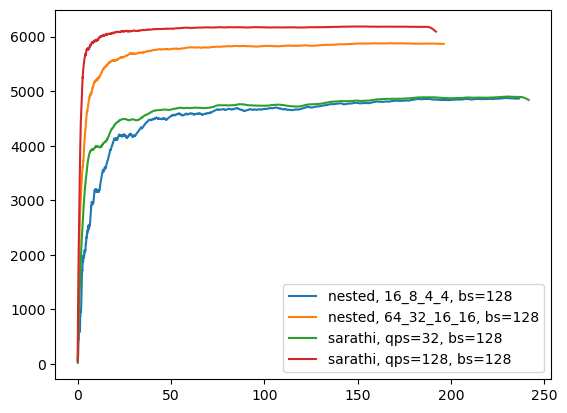

In [7]:
import matplotlib.pyplot as plt

plt.plot(nested1["Time (sec)"], nested1["throughput/t"], label="nested, 16_8_4_4, bs=128")
plt.plot(nested2["Time (sec)"], nested2["throughput/t"], label="nested, 64_32_16_16, bs=128")
plt.plot(sarathi1["Time (sec)"], sarathi1["throughput/t"], label="sarathi, qps=32, bs=128")
plt.plot(sarathi2["Time (sec)"], sarathi2["throughput/t"], label="sarathi, qps=128, bs=128")
plt.legend()
plt.show()

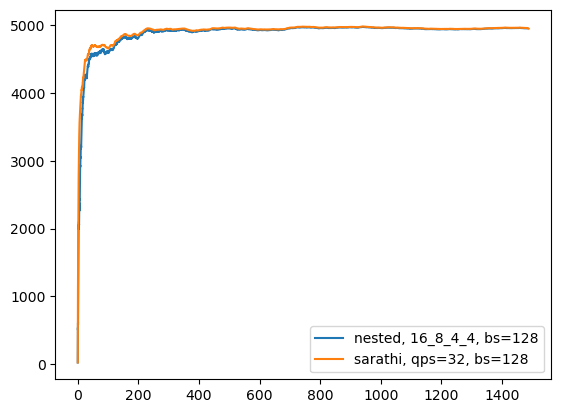

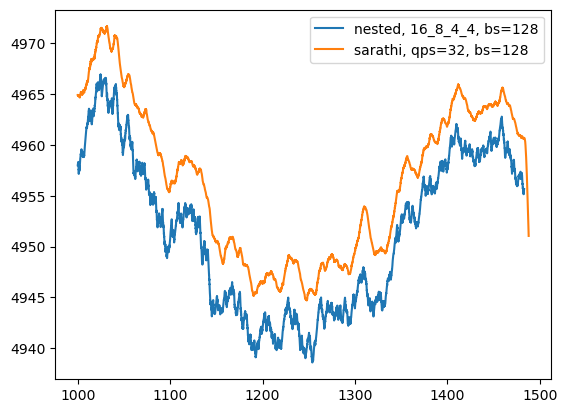

In [8]:
import pandas as pd

nested11 = pd.read_csv("./4e5_reqs/throughput_general_nested_booking_limit_limit_129_qps=32_rates=_16_8_4_4_batch_size_127.csv")


sarathi11 = pd.read_csv("./4e5_reqs/throughput_sarathi_batch_size_128_qps=32.csv")

dfs = [nested11,sarathi11]
for df in dfs:
    df["throughput/t"] = df["throughput"] / df["Time (sec)"]

import matplotlib.pyplot as plt

plt.plot(nested11["Time (sec)"], nested11["throughput/t"], label="nested, 16_8_4_4, bs=128")
plt.plot(sarathi11["Time (sec)"], sarathi11["throughput/t"], label="sarathi, qps=32, bs=128")
plt.legend()
plt.show()

# 过滤 Time (sec) > 1000 的数据
nested11_filtered = nested11[nested11["Time (sec)"] > 1000]
sarathi11_filtered = sarathi11[sarathi11["Time (sec)"] > 1000]

plt.plot(nested11_filtered["Time (sec)"], nested11_filtered["throughput/t"], label="nested, 16_8_4_4, bs=128")
plt.plot(sarathi11_filtered["Time (sec)"], sarathi11_filtered["throughput/t"], label="sarathi, qps=32, bs=128")
plt.legend()
plt.show()

# import matplotlib.pyplot as plt

# a = 2000

# nested11 = nested11[a:]
# sarathi11 = sarathi11[a:]

# plt.plot(nested11["Time (sec)"], nested11["throughput/t"], label="nested, 16_8_4_4, bs=128")
# plt.plot(sarathi11["Time (sec)"], sarathi11["throughput/t"], label="sarathi, qps=32, bs=128")
# plt.legend()
# plt.show()

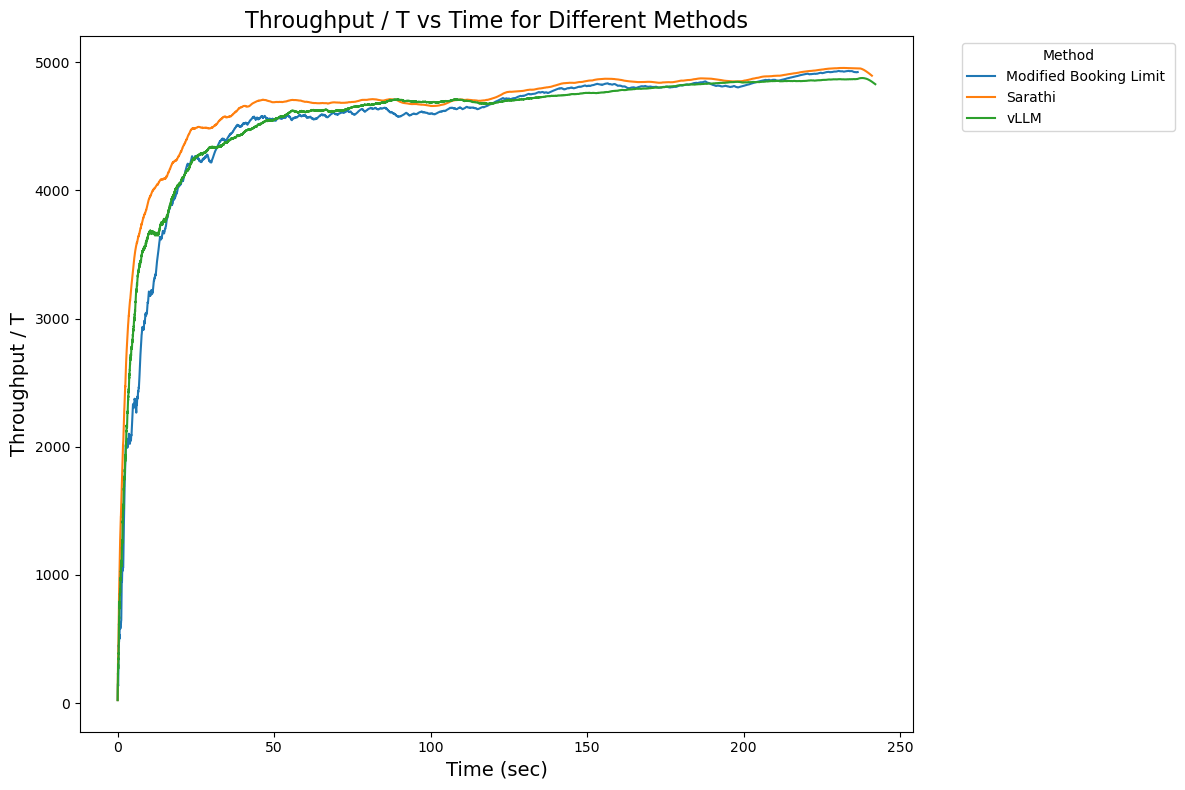

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 定义文件路径
file_paths = [
    "./DRAW/throughput_general_nested_booking_limit_limit_129, nested_real_qps=32_rates=_16_8_4_4_batch_size_127.csv",
    "./DRAW/throughput_sarathi_batch_size_128_qps=32, sarathi.csv",
    "./DRAW/throughput_vllm_batch_size_128, vllm.csv"
]

# 定义每条曲线的标签
labels = [
    'Modified Booking Limit ',
    'Sarathi',
    'vLLM'
]

# 创建一个新的图表
plt.figure(figsize=(12, 8))

# 遍历每个文件
for file_path, label in zip(file_paths, labels):
    # 使用pandas读取CSV文件
    df = pd.read_csv(file_path)
    
    # 计算 T时刻的throughput / T
    df['throughput_per_T'] = df['throughput'] / df['Time (sec)']
    
    # 绘制throughput_per_T随时间变化的曲线
    plt.plot(df['Time (sec)'], df['throughput_per_T'], label=label)

# 添加图例
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# 添加标题和标签
plt.title('Throughput / T vs Time for Different Methods', fontsize=16)
plt.xlabel('Time (sec)', fontsize=14)
plt.ylabel('Throughput / T', fontsize=14)

# 调整布局，防止图例遮挡
plt.tight_layout()

# 显示图表
plt.show()

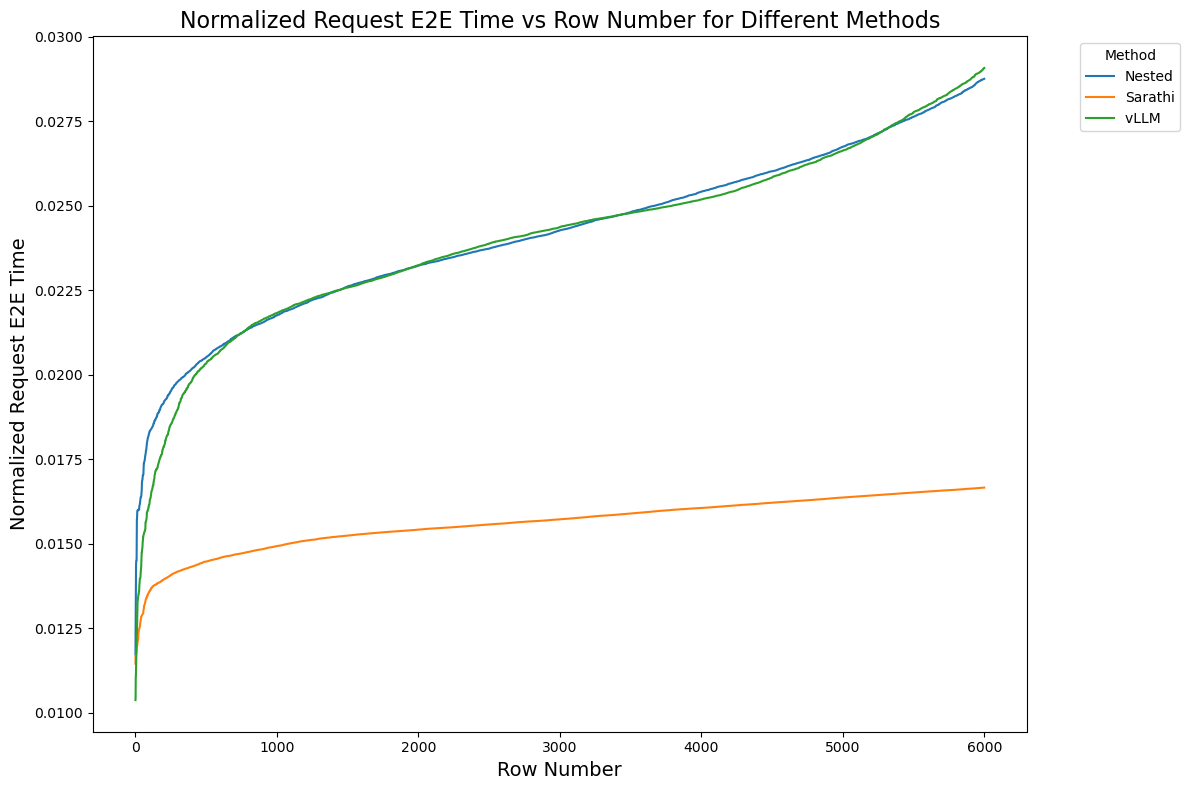

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 定义 request e2e time 文件路径
e2e_file_paths = [
    "./DRAW/request_e2e_time_normalized_limit_129, nested_real_qps=32_rates=_16_8_4_4.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_128_qps=32, sarathi.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_128, vllm.csv"
]

# 定义每条曲线的标签
labels = [
    'Nested',
    'Sarathi',
    'vLLM '
]

# 创建一个新的图表
plt.figure(figsize=(12, 8))

a=6000

# 遍历每个 request e2e time 文件
for file_path, label in zip(e2e_file_paths, labels):
    # 读取数据
    df_e2e = pd.read_csv(file_path)
    
    # 绘制 request_e2e_time_normalized 对应的行数
    plt.plot(df_e2e.index[:a], df_e2e['request_e2e_time_normalized'][:a], label=label)

# 添加图例
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# 添加标题和标签
plt.title('Normalized Request E2E Time vs Row Number for Different Methods', fontsize=16)
plt.xlabel('Row Number', fontsize=14)
plt.ylabel('Normalized Request E2E Time', fontsize=14)

# 调整布局，防止图例遮挡
plt.tight_layout()

# 显示图表
plt.show()


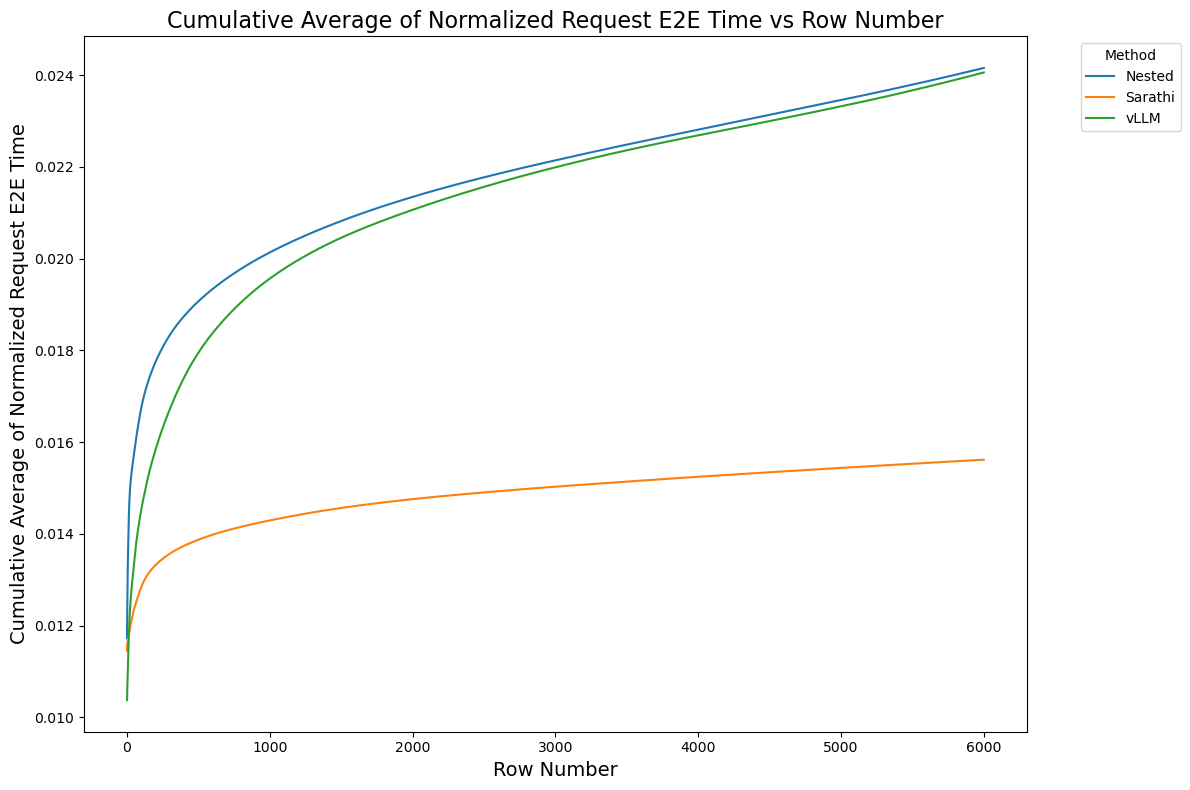

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 定义 request e2e time 文件路径
e2e_file_paths = [
    "./DRAW/request_e2e_time_normalized_limit_129, nested_real_qps=32_rates=_16_8_4_4.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_128_qps=32, sarathi.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_128, vllm.csv"
]

# 定义每条曲线的标签
labels = [
    'Nested',
    'Sarathi',
    'vLLM'
]

# 创建一个新的图表
plt.figure(figsize=(12, 8))

a = 6000  # 只绘制前 a 行数据

# 遍历每个 request e2e time 文件
for file_path, label in zip(e2e_file_paths, labels):
    # 读取数据
    df_e2e = pd.read_csv(file_path)
    
    # 计算前 t 行的均值
    df_e2e['cumulative_avg'] = df_e2e['request_e2e_time_normalized'].expanding().mean()
    
    # 绘制行索引 vs 累计均值
    plt.plot(df_e2e.index[:a], df_e2e['cumulative_avg'][:a], label=label)

# 添加图例
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# 添加标题和标签
plt.title('Cumulative Average of Normalized Request E2E Time vs Row Number', fontsize=16)
plt.xlabel('Row Number', fontsize=14)
plt.ylabel('Cumulative Average of Normalized Request E2E Time', fontsize=14)

# 调整布局，防止图例遮挡
plt.tight_layout()

# 显示图表
plt.show()


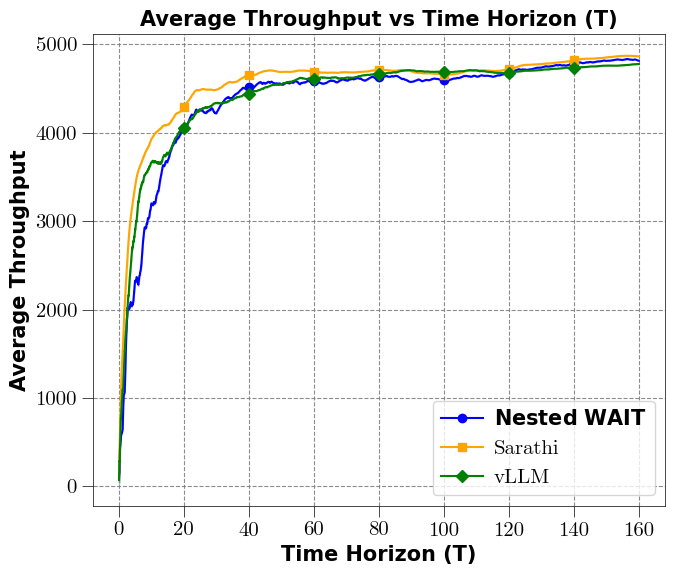

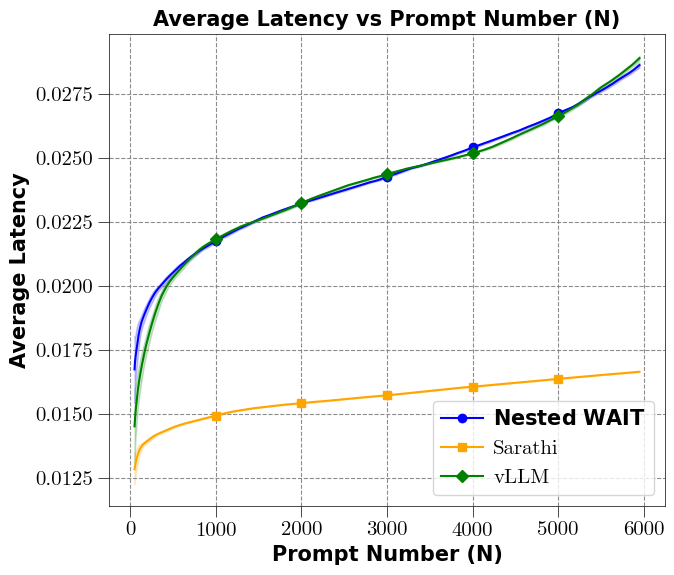

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

add = "test39_simulated_short_decode_bs=128_nested_real_TRACE"

file_paths_throughput = [
    "./DRAW/throughput_general_nested_booking_limit_limit_129, nested_real_qps=32_rates=_16_8_4_4_batch_size_127.csv",
    "./DRAW/throughput_sarathi_batch_size_128_qps=32, sarathi.csv",
    "./DRAW/throughput_vllm_batch_size_128, vllm.csv"
]
labels_e2e = ['Nested WAIT', 'Sarathi', 'vLLM']
s = 160

e2e_file_paths = [
    "./DRAW/request_e2e_time_normalized_limit_129, nested_real_qps=32_rates=_16_8_4_4.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_128_qps=32, sarathi.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_128, vllm.csv"
]
a = 6000

# 设置 CMU Serif 字体
font_path = "/Users/luogan/Library/Fonts/CMU Serif Roman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 设置全局样式，但避免 Seaborn 覆盖刻度
plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (8, 7)
})

# 绘制第一个图：Throughput / T vs Time
plt.figure(figsize=(7, 6))
markers = ['o', 's', 'D']  # 圆圈、正方形、菱形
colors = ['blue', 'orange', 'green']

# 设置x轴刻度
xticks = np.arange(0, s + 20, 20)

for file_path, label, marker, color in zip(file_paths_throughput, labels_e2e, markers, colors):
    df = pd.read_csv(file_path)
    df['throughput_per_T'] = df['throughput'] / df['Time (sec)']
    df_filtered = df[df['Time (sec)'] < s]
    
    window = 5
    rolling_mean = df_filtered['throughput_per_T'].rolling(window=window, center=True).mean()
    rolling_std = df_filtered['throughput_per_T'].rolling(window=window, center=True).std()
    
    plt.fill_between(df_filtered['Time (sec)'],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color=color, alpha=0.2)
    
    plt.plot(df_filtered['Time (sec)'], rolling_mean,
             color=color, label=label, linestyle='-')
    
    for tick in xticks:
        closest_idx = (df_filtered['Time (sec)'] - tick).abs().idxmin()
        plt.plot(df_filtered['Time (sec)'].iloc[closest_idx], 
                rolling_mean.iloc[closest_idx], 
                color=color, marker=marker, markersize=6)

plt.title('Average Throughput vs Time Horizon (T)', fontsize=15, weight='bold')
plt.xlabel('Time Horizon (T)', fontsize=15, weight='bold')
plt.ylabel('Average Throughput', fontsize=15, weight='bold')

handles, labels = plt.gca().get_legend_handles_labels()
new_handles = []
for handle, label, marker, color in zip(handles, labels, markers, colors):
    new_handle = plt.Line2D([], [], color=color, linestyle='-', marker=marker, markersize=6, label=label)
    new_handles.append(new_handle)

for i, label in enumerate(labels):
    if label == 'WAIT':
        labels[i] = r"$\bf{WAIT}$"
    if label == 'Nested WAIT':
        labels[i] = r"$\bf{Nested\ WAIT}$"

plt.legend(new_handles, labels, loc='lower right', prop=font_prop, scatterpoints=1, handletextpad=0.5)

plt.xticks(xticks, fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

# 设置网格线样式（手动添加，避免 Seaborn 干扰）
plt.grid(True, linestyle='--', alpha=0.9, color='gray')

# 设置边框
plt.gca().spines['top'].set_color('black')
plt.gca().spines['top'].set_linewidth(0.5)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['right'].set_linewidth(0.5)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(0.5)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['left'].set_linewidth(0.5)

# 设置刻度线向外延伸（放在最后，确保生效）
plt.tick_params(axis='both', which='major', direction='out', length=8, width=0.5)

plt.tight_layout()
plt.savefig(f"/Users/luogan/Code/vidur_or/PDF/{add}_throughput.pdf")
plt.show()

# 绘制第二个图：Normalized Request E2E Time vs Row Number
plt.figure(figsize=(7, 6))

xticks = np.arange(0, a + 1000, 1000)

for file_path, label, marker, color in zip(e2e_file_paths, labels_e2e, markers, colors):
    df_e2e = pd.read_csv(file_path)
    
    window = 100
    rolling_mean = df_e2e['request_e2e_time_normalized'][:a].rolling(window=window, center=True).mean()
    rolling_std = df_e2e['request_e2e_time_normalized'][:a].rolling(window=window, center=True).std()
    
    plt.fill_between(df_e2e.index[:a],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color=color, alpha=0.2)
    
    plt.plot(df_e2e.index[:a], rolling_mean,
             color=color, label=label, linestyle='-')
    
    for tick in xticks:
        if tick < a:
            closest_idx = min(tick, len(df_e2e.index[:a]) - 1)
            plt.plot(df_e2e.index[int(closest_idx)], 
                    rolling_mean.iloc[int(closest_idx)], 
                    color=color, marker=marker, markersize=6)

plt.title('Average Latency vs Prompt Number (N)', fontsize=15, weight='bold')
plt.xlabel('Prompt Number (N)', fontsize=15, weight='bold')
plt.ylabel('Average Latency', fontsize=15, weight='bold')

handles, labels = plt.gca().get_legend_handles_labels()
new_handles = []
for handle, label, marker, color in zip(handles, labels, markers, colors):
    new_handle = plt.Line2D([], [], color=color, linestyle='-', marker=marker, markersize=6, label=label)
    new_handles.append(new_handle)

for i, label in enumerate(labels):
    if label == 'WAIT':
        labels[i] = r"$\bf{WAIT}$"
    if label == 'Nested WAIT':
        labels[i] = r"$\bf{Nested\ WAIT}$"

plt.legend(new_handles, labels, loc='lower right', prop=font_prop, scatterpoints=1, handletextpad=0.5)

plt.xticks(xticks, fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

# 设置网格线样式
plt.grid(True, linestyle='--', alpha=0.9, color='gray')

plt.gca().spines['top'].set_color('black')
plt.gca().spines['top'].set_linewidth(0.5)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['right'].set_linewidth(0.5)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(0.5)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['left'].set_linewidth(0.5)

# 设置刻度线向外延伸（放在最后，确保生效）
plt.tick_params(axis='both', which='major', direction='out', length=8, width=0.5)

plt.tight_layout()
plt.savefig(f"/Users/luogan/Code/vidur_or/PDF/{add}_latency.pdf")
plt.show()